# Centralized MAML Training Results (Step 7 Gate)

**Goal:** Visualise the results of `python maml/meta_train.py` and confirm the Step 7 gate:
> WER(k=3) < WER(k=0) on ≥ 4/5 nodes

**Inputs (generated by `maml/meta_train.py`):**
- `checkpoints/centralized/step7_results.json` — per-node WER(k=0) and WER(k=3)
- `checkpoints/centralized/training_metrics.json` — per-round average query loss

**Visuals:**
- A — Training loss curve (per round)
- B — WER grouped bar chart (k=0 vs k=3 per node)
- C — WER improvement percentage per node
- D — Summary scorecard

In [1]:
import json, os, sys
from pathlib import Path

REPO = Path(os.path.abspath(".")).parent
CKPT = REPO / "checkpoints" / "centralized"

results_path = CKPT / "step7_results.json"
metrics_path = CKPT / "training_metrics.json"

if not results_path.exists():
    raise FileNotFoundError(
        f"{results_path} not found.\n"
        "Run:  conda run -n voicefl python maml/meta_train.py --config configs/poc.yaml"
    )

with open(results_path) as f:
    wer_results = json.load(f)   # {node_hash: {wer_k0, wer_k3, passed}}

train_metrics = []
if metrics_path.exists():
    with open(metrics_path) as f:
        train_metrics = json.load(f)   # [{round, avg_query_loss}, ...]

print(f"Nodes in results: {len(wer_results)}")
print(f"Training rounds:  {len(train_metrics)}")

Nodes in results: 5
Training rounds:  20


In [2]:
# ── Parse results ────────────────────────────────────────────────────────────
node_names = [f"Node {i+1}" for i in range(len(wer_results))]
node_data  = list(wer_results.values())

wer_k0   = [d["wer_k0"]   for d in node_data]
wer_k3   = [d["wer_k3"]   for d in node_data]
passed   = [d["passed"]   for d in node_data]
improve_pct = [(k0 - k3) / max(k0, 1e-6) * 100 for k0, k3 in zip(wer_k0, wer_k3)]

n_passed = sum(passed)
gate_ok  = n_passed >= 4

print(f"{'Node':<10} {'WER(k=0)':>10} {'WER(k=3)':>10} {'Improve%':>10}  Gate")
print("-" * 50)
for name, k0, k3, imp, ok in zip(node_names, wer_k0, wer_k3, improve_pct, passed):
    flag = "PASS" if ok else "FAIL"
    print(f"{name:<10} {k0:>10.3f} {k3:>10.3f} {imp:>9.1f}%  {flag}")
print(f"\nGate: {n_passed}/{len(wer_results)} nodes passed (need 4)")

Node         WER(k=0)   WER(k=3)   Improve%  Gate
--------------------------------------------------
Node 1          0.044      0.036      16.7%  PASS
Node 2          0.082      0.032      60.9%  PASS
Node 3          0.031      0.007      77.8%  PASS
Node 4          0.017      0.014      20.0%  PASS
Node 5          0.040      0.017      57.1%  PASS

Gate: 5/5 nodes passed (need 4)


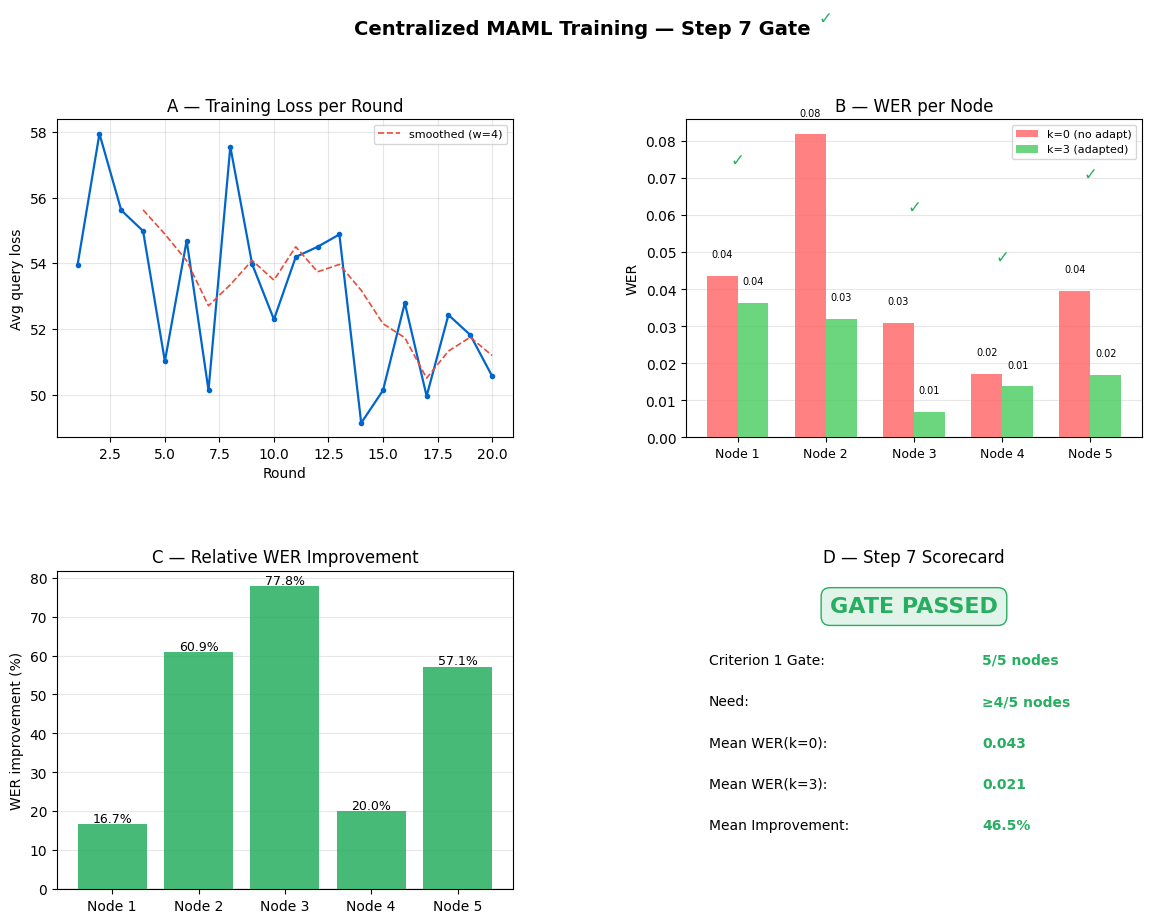

Saved: notebooks/data/step7_results.png

Step 7 gate: PASSED (5/5 nodes)


In [3]:
# ── Figure: 2×2 training + WER summary ──────────────────────────────────────
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import numpy as np

fig = plt.figure(figsize=(14, 10))
fig.suptitle("Centralized MAML Training — Step 7 Gate", fontsize=14, fontweight="bold", y=0.98)
gs = gridspec.GridSpec(2, 2, figure=fig, hspace=0.42, wspace=0.38)

# ── Panel A: Training loss curve ─────────────────────────────────────────────
ax_a = fig.add_subplot(gs[0, 0])
if train_metrics:
    rounds = [m["round"] for m in train_metrics]
    losses = [m["avg_query_loss"] for m in train_metrics]
    ax_a.plot(rounds, losses, color="#0066cc", linewidth=1.6, marker="o", markersize=3)
    # Smooth if enough points
    if len(losses) >= 5:
        window = max(2, len(losses) // 5)
        smooth = np.convolve(losses, np.ones(window) / window, mode="valid")
        ax_a.plot(rounds[window - 1:], smooth, color="#e74c3c",
                  linewidth=1.2, linestyle="--", label=f"smoothed (w={window})")
        ax_a.legend(fontsize=8)
    ax_a.set_xlabel("Round")
    ax_a.set_ylabel("Avg query loss")
    ax_a.set_title("A — Training Loss per Round")
    ax_a.grid(True, alpha=0.3)
else:
    ax_a.text(0.5, 0.5, "training_metrics.json\nnot found", ha="center", va="center",
              transform=ax_a.transAxes, fontsize=10, color="gray")
    ax_a.set_title("A — Training Loss (unavailable)")

# ── Panel B: WER grouped bar chart ──────────────────────────────────────────
ax_b = fig.add_subplot(gs[0, 1])
x = np.arange(len(node_names))
w = 0.35
bars0 = ax_b.bar(x - w / 2, wer_k0, width=w, label="k=0 (no adapt)",
                 color="#ff6b6b", alpha=0.85, zorder=3)
bars3 = ax_b.bar(x + w / 2, wer_k3, width=w, label="k=3 (adapted)",
                 color="#51cf66", alpha=0.85, zorder=3)
# Annotate each bar
for bar in list(bars0) + list(bars3):
    ax_b.text(bar.get_x() + bar.get_width() / 2,
              bar.get_height() + 0.005, f"{bar.get_height():.2f}",
              ha="center", fontsize=7)
ax_b.set_xticks(x)
ax_b.set_xticklabels(node_names, fontsize=9)
ax_b.set_ylabel("WER")
ax_b.set_title("B — WER per Node")
ax_b.legend(fontsize=8)
ax_b.grid(True, axis="y", alpha=0.3)
# Mark passing/failing nodes
for i, ok in enumerate(passed):
    color = "#27ae60" if ok else "#e74c3c"
    ax_b.text(i, max(wer_k0[i], wer_k3[i]) + 0.03, "✓" if ok else "✗",
              ha="center", color=color, fontsize=12, fontweight="bold")

# ── Panel C: Improvement % per node ─────────────────────────────────────────
ax_c = fig.add_subplot(gs[1, 0])
bar_colors_c = ["#27ae60" if v > 0 else "#e74c3c" for v in improve_pct]
ax_c.bar(node_names, improve_pct, color=bar_colors_c, alpha=0.85, zorder=3)
ax_c.axhline(0, color="black", linewidth=0.8)
ax_c.set_ylabel("WER improvement (%)")
ax_c.set_title("C — Relative WER Improvement")
ax_c.grid(True, axis="y", alpha=0.3)
for i, (name, val) in enumerate(zip(node_names, improve_pct)):
    offset = 0.5 if val >= 0 else -1.5
    ax_c.text(i, val + offset, f"{val:.1f}%", ha="center", fontsize=9)

# ── Panel D: Scorecard ───────────────────────────────────────────────────────
ax_d = fig.add_subplot(gs[1, 1])
ax_d.axis("off")
summary_lines = [
    ("Criterion 1 Gate",    f"{n_passed}/{len(wer_results)} nodes",  gate_ok),
    ("Need",                f"≥4/{len(wer_results)} nodes",           True),
    ("Mean WER(k=0)",       f"{sum(wer_k0)/len(wer_k0):.3f}",         True),
    ("Mean WER(k=3)",       f"{sum(wer_k3)/len(wer_k3):.3f}",         True),
    ("Mean Improvement",    f"{sum(improve_pct)/len(improve_pct):.1f}%", sum(improve_pct) > 0),
]
gate_color  = "#27ae60" if gate_ok else "#e74c3c"
gate_banner = "GATE PASSED" if gate_ok else "GATE FAILED"
ax_d.text(0.5, 0.92, gate_banner, transform=ax_d.transAxes, ha="center", va="top",
          fontsize=16, fontweight="bold", color=gate_color,
          bbox=dict(boxstyle="round,pad=0.4", facecolor=gate_color + "22", edgecolor=gate_color))
for i, (label, value, ok) in enumerate(summary_lines):
    ypos = 0.72 - i * 0.13
    ax_d.text(0.05, ypos, label + ":", transform=ax_d.transAxes, fontsize=10, va="center")
    ax_d.text(0.65, ypos, value,       transform=ax_d.transAxes, fontsize=10, va="center",
              fontweight="bold", color="#27ae60" if ok else "#e74c3c")
ax_d.set_title("D — Step 7 Scorecard")

save_dir = Path(os.path.dirname(os.path.abspath("03_centralized_train.ipynb"))) / "data"
save_dir.mkdir(exist_ok=True)
plt.savefig(str(save_dir / "step7_results.png"), dpi=100, bbox_inches="tight")
plt.show()
print(f"Saved: notebooks/data/step7_results.png")
print(f"\nStep 7 gate: {'PASSED' if gate_ok else 'FAILED'} ({n_passed}/{len(wer_results)} nodes)")

In [4]:
# ── Assert gate ──────────────────────────────────────────────────────────────
assert gate_ok, (
    f"Step 7 gate FAILED: only {n_passed}/{len(wer_results)} nodes have WER(k=3) < WER(k=0). "
    "Re-run meta_train.py with more rounds or check the MAML engine."
)
print("Assertion passed — all good to proceed to Step 8 (Docker build).")

Assertion passed — all good to proceed to Step 8 (Docker build).
